In [5]:
import os
print(os.listdir('/content/'))

['.config', 'HDO Results.csv', 'sample_data']


In [6]:
import pandas as pd
df = pd.read_csv('/content/HDO Results.csv', encoding='latin-1', sep=';', header=1)
df.columns = df.columns.str.strip()
df = df.rename(columns={'Unnamed: 0': 'Case'})
cols_angka = df.columns.drop('Case')
df[cols_angka] = df[cols_angka].astype(str).applymap(
    lambda x: x.strip().replace(',', '.').replace('%', '')
).astype(float)

df_clean = df[df['Yield (%)'] > 0].copy()

print(df.head())
print(df_clean.head())
print(df.dtypes)
print(df.shape)
print(df.columns)

     Case  Temperature (°C)  Pressure (Bar)  H2 Feeding (Kg)       C17H34  \
0  Case 1             300.0            80.0            300.0  7871.063823   
1  Case 2             300.0            80.0            350.0  7866.682154   
2  Case 3             300.0            80.0            400.0  7863.431037   
3  Case 4             300.0            90.0            300.0  7858.197096   
4  Case 5             300.0            90.0            350.0  7853.513170   

      C17H36      C18H38  Q reactor (KJ)  Yield (%)  Selectivity (%)  \
0  75.034910  142.010862    -680233.8638    80.8811          77.7703   
1  76.128429  145.531926    -576700.4013    80.8834          77.7725   
2  76.934391  148.148645    -473036.3188    80.8851          77.7742   
3  78.221804  152.371098    -707748.6777    80.8879          77.7768   
4  79.364077  156.159652    -605965.8048    80.8904          77.7792   

   Steam 30 Bar superheted (Kg)  Cooling Water 30°C (Kg)  \
0                           0.0             

/tmp/ipykernel_5982/4257765735.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[cols_angka] = df[cols_angka].astype(str).applymap(


Plot berhasil disave sebagai HDO_Yied_vs_Pressure_Temperature.png


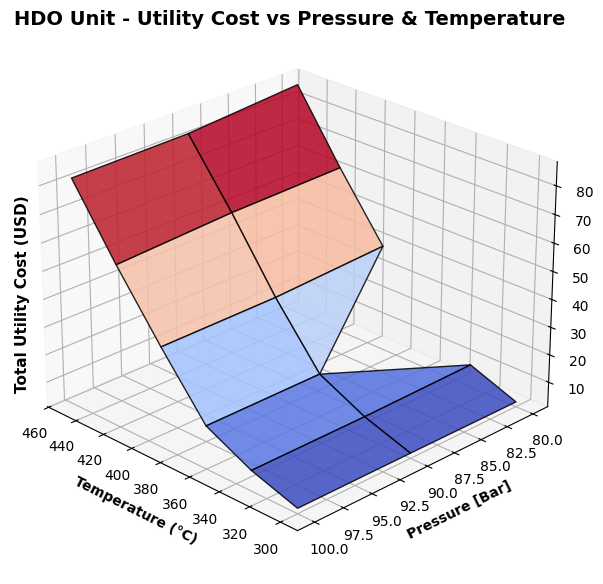

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

T_grid = sorted(df_clean['Temperature (°C)'].unique())
P_grid = sorted(df_clean['Pressure (Bar)'].unique())
T_mesh, P_mesh = np.meshgrid(T_grid, P_grid)

Z_mesh = df_clean.groupby(['Pressure (Bar)', 'Temperature (°C)'])['Total Utility Cost (USD)'].mean().unstack().values
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_mesh, P_mesh, Z_mesh, cmap=cm.coolwarm, alpha=0.85, edgecolor='k')
ax.set_xlabel('Temperature (°C)', fontweight='bold')
ax.set_ylabel('Pressure [Bar]', fontweight='bold')
plt.title('HDO Unit - Utility Cost vs Pressure & Temperature', y=1.05, fontweight='bold', fontsize=14)

fig.text(0.25, 0.5, 'Total Utility Cost (USD)',
         rotation=90, fontweight='bold', fontsize=11, va='center')

ax.view_init(elev=25, azim=135)
plt.subplots_adjust(left=0.2, right=0.85, bottom=0.1, top=0.9)
plt.savefig('HDO_Yied_vs_Pressure_Temperature.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Plot berhasil disave sebagai HDO_Yied_vs_Pressure_Temperature.png")
plt.show()

=== TITIK OPTIMUM HDO UNIT (COSS PER UNIT) ===
Temperature Optimal     : 300.0 °C
Pressure Optimal        : 80.0 Bar
Cost per Unit           : $0.0280 / %Yield
Yield in this condition : 80.89%

 Plot successed save as: HDO_CostPerUnit_Optimum.png


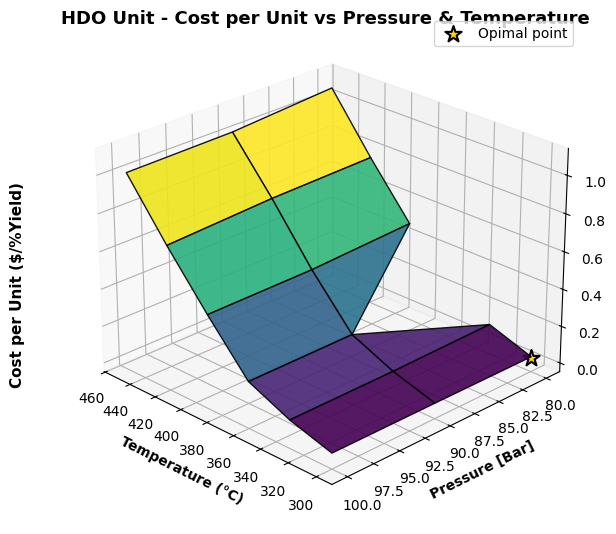

In [8]:
df_clean['Cost per Unit'] = df_clean['Total Utility Cost (USD)'] / df_clean['Yield (%)']

z_mesh_cost_per_unit = df_clean.groupby(['Pressure (Bar)', 'Temperature (°C)'])['Cost per Unit'].mean().unstack().values

min_idx = df_clean['Cost per Unit'].idxmin()
opt_temp = df_clean.loc[min_idx, 'Temperature (°C)']
opt_press = df_clean.loc[min_idx, 'Pressure (Bar)']
opt_cost_unit = df_clean.loc[min_idx, 'Cost per Unit']
opt_yield = df_clean.loc[min_idx, 'Yield (%)']

print("=== TITIK OPTIMUM HDO UNIT (COSS PER UNIT) ===")
print(f"Temperature Optimal     : {opt_temp} °C")
print(f"Pressure Optimal        : {opt_press} Bar")
print(f"Cost per Unit           : ${opt_cost_unit:.4f} / %Yield")
print(f"Yield in this condition : {opt_yield:.2f}%")
print("==============================================")

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_mesh, P_mesh, z_mesh_cost_per_unit, cmap=cm.viridis, alpha=0.9, edgecolor='k')

ax.scatter(opt_temp, opt_press, opt_cost_unit, color='gold', s=150, marker='*', edgecolor='black', linewidth=1.5, label='Opimal point')

ax.set_xlabel('Temperature (°C)', fontweight='bold')
ax.set_ylabel('Pressure [Bar]', fontweight='bold')
plt.title('HDO Unit - Cost per Unit vs Pressure & Temperature', y=1.05, fontweight='bold', fontsize=13)
fig.text(0.25, 0.5, 'Cost per Unit ($/%Yield)', rotation=90, fontweight='bold', fontsize=11, va='center')

ax.view_init(elev=25, azim=135)
ax.legend(loc='upper right')
plt.subplots_adjust(left=0.3, right=0.9, bottom=0.1, top=0.95)

plt.savefig('HDO_CostPerUnit_Optimum.png', dpi=300, bbox_inches='tight')
print("\n Plot successed save as: HDO_CostPerUnit_Optimum.png")

plt.show()

=== TITIK OPTIMUM HDO UNIT (COST PER UNIT) ===
Temperature Optimal : 300.0 °C
Pressure Optimal: 80.0 Bar
Yield in this Condition : 80.8851%
Cost per Unit : $0.027978 / %Yield

Plot successfull save as: HDO_CostPerUnit_Yield_ColorMap.png


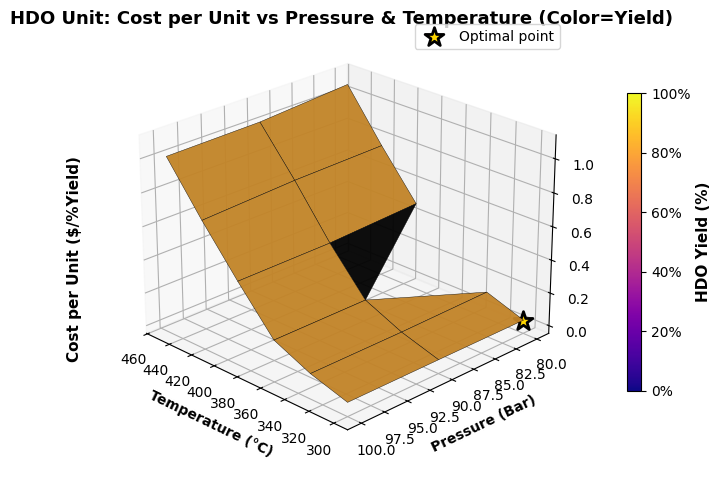

In [16]:
import matplotlib.pyplot as plt
from matplotlib import cm

if 'Cost per Unit' not in df_clean.columns:
    df_clean['Cost per Unit'] = df_clean['Total Utility cost'] / df_clean['Yiel (%)']

T_grid = sorted(df_clean['Temperature (°C)'].unique())
P_grid = sorted(df_clean['Pressure (Bar)'].unique())
T_mesh, P_mesh = np.meshgrid(T_grid, P_grid)

Z_cost = df_clean.groupby(['Pressure (Bar)', 'Temperature (°C)'])['Cost per Unit'].mean().unstack().values
Z_yield = df_clean.groupby(['Pressure (Bar)', 'Temperature (°C)'])['Yield (%)'].mean().unstack().values

min_idx = df_clean['Cost per Unit'].idxmin()
opt_temp= df_clean.loc[min_idx, 'Temperature (°C)']
opt_press = df_clean.loc[min_idx, 'Pressure (Bar)']
opt_cost_unit = df_clean.loc[min_idx, 'Cost per Unit']
opt_yield = df_clean.loc[min_idx, 'Yield (%)']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_mesh, P_mesh, Z_cost, facecolors=cm.plasma(Z_yield/100), alpha=0.95, edgecolor='k', linewidth=0.3)

m = cm.ScalarMappable(cmap=cm.plasma)
cbar = fig.colorbar(m, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('HDO Yield (%)', fontweight='bold', fontsize=11)
import matplotlib.ticker as mtick
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax.scatter(opt_temp, opt_press, opt_cost_unit, color='gold', s=200, marker='*', edgecolor='black', linewidth=2, label='Optimal point')

ax.set_xlabel('Temperature (°C)', fontweight='bold')
ax.set_ylabel('Pressure (Bar)', fontweight='bold')
plt.title('HDO Unit: Cost per Unit vs Pressure & Temperature (Color=Yield)', y=1.05, fontweight='bold', fontsize=13)
fig.text(0.25, 0.5, 'Cost per Unit ($/%Yield)', rotation=90, fontweight='bold', fontsize=11, va='center')

ax.view_init(elev=24, azim=135)
ax.legend(loc='upper right')
plt.subplots_adjust(left=0.3, right=0.9, bottom=0.1, top=0.95)

plt.savefig('HDO_CostPerUnit_Yield_ColorMap.png', dpi=300, bbox_inches='tight')
print("=== TITIK OPTIMUM HDO UNIT (COST PER UNIT) ===")
print(f"Temperature Optimal : {opt_temp} °C")
print(f"Pressure Optimal: {opt_press} Bar")
print(f"Yield in this Condition : {opt_yield:.4f}%")
print(f"Cost per Unit : ${opt_cost_unit:.6f} / %Yield")
print("===============================================")
print("\nPlot successfull save as: HDO_CostPerUnit_Yield_ColorMap.png")
plt.show()